In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
# Load datasets

nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

transactions = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")

performance = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_cleaned.csv")

In [3]:
print("NAV Shape:", nav.shape)
print("Transactions Shape:", transactions.shape)
print("Performance Shape:", performance.shape)
print("Portfolio Shape:", portfolio.shape)

NAV Shape: (46000, 3)
Transactions Shape: (32778, 13)
Performance Shape: (40, 19)
Portfolio Shape: (322, 8)


In [4]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [5]:
nav["date"] = pd.to_datetime(nav["date"])

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [6]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')


In [7]:
print(transactions.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')


In [8]:
nav = nav.sort_values(["amfi_code", "date"])

In [9]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

In [10]:
nav = nav.dropna(subset=["daily_return"])

In [11]:
risk_metrics = []

for amfi_code, group in nav.groupby("amfi_code"):

    var95 = np.percentile(group["daily_return"], 5)

    cvar95 = group[group["daily_return"] <= var95]["daily_return"].mean()

    risk_metrics.append({
        "amfi_code": amfi_code,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

risk_df = pd.DataFrame(risk_metrics)

risk_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [12]:
risk_df.to_csv("../reports/var_cvar_report.csv", index=False)

print("Saved successfully!")

Saved successfully!


In [13]:
risk_df.describe()

,amfi_code,VaR_95,CVaR_95
count,40.000000,40.000000,40.000000
mean,120247.000000,-0.014711,-0.018580
std,14534.998667,0.006821,0.008476
min,100016.000000,-0.026859,-0.032459
25%,118632.750000,-0.018394,-0.023133
50%,119551.500000,-0.014376,-0.018185
75%,120842.250000,-0.013247,-0.016572
max,149324.000000,-0.000222,-0.000373


In [14]:
risk_df.sort_values("VaR_95").head(10)

,amfi_code,VaR_95,CVaR_95
22,119599,-0.026859,-0.032384
17,119095,-0.026188,-0.031667
4,101207,-0.026021,-0.032459
11,118634,-0.025438,-0.032304
21,119598,-0.024507,-0.030595
39,149324,-0.023483,-0.031036
7,102886,-0.019220,-0.023251
2,100033,-0.019034,-0.023456
25,120505,-0.018892,-0.024342
16,119094,-0.018480,-0.024260


In [15]:
top5_funds = nav["amfi_code"].unique()[:5]

print(top5_funds)

[100016 100025 100033 101206 101207]


In [16]:
rolling_data = []

for fund in top5_funds:

    temp = nav[nav["amfi_code"] == fund].copy()

    temp = temp.sort_values("date")

    temp["rolling_mean"] = temp["daily_return"].rolling(90).mean()

    temp["rolling_std"] = temp["daily_return"].rolling(90).std()

    temp["Sharpe"] = (
        temp["rolling_mean"] /
        temp["rolling_std"]
    ) * np.sqrt(252)

    temp["amfi_code"] = fund

    rolling_data.append(temp)

rolling_df = pd.concat(rolling_data)

rolling_df.head()

,amfi_code,date,nav,daily_return,rolling_mean,rolling_std,Sharpe
1,100016,2022-01-04,515.0971,-0.010306,NaN,NaN,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN,NaN,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN,NaN,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN,NaN,NaN
5,100016,2022-01-10,510.7136,-0.008639,NaN,NaN,NaN


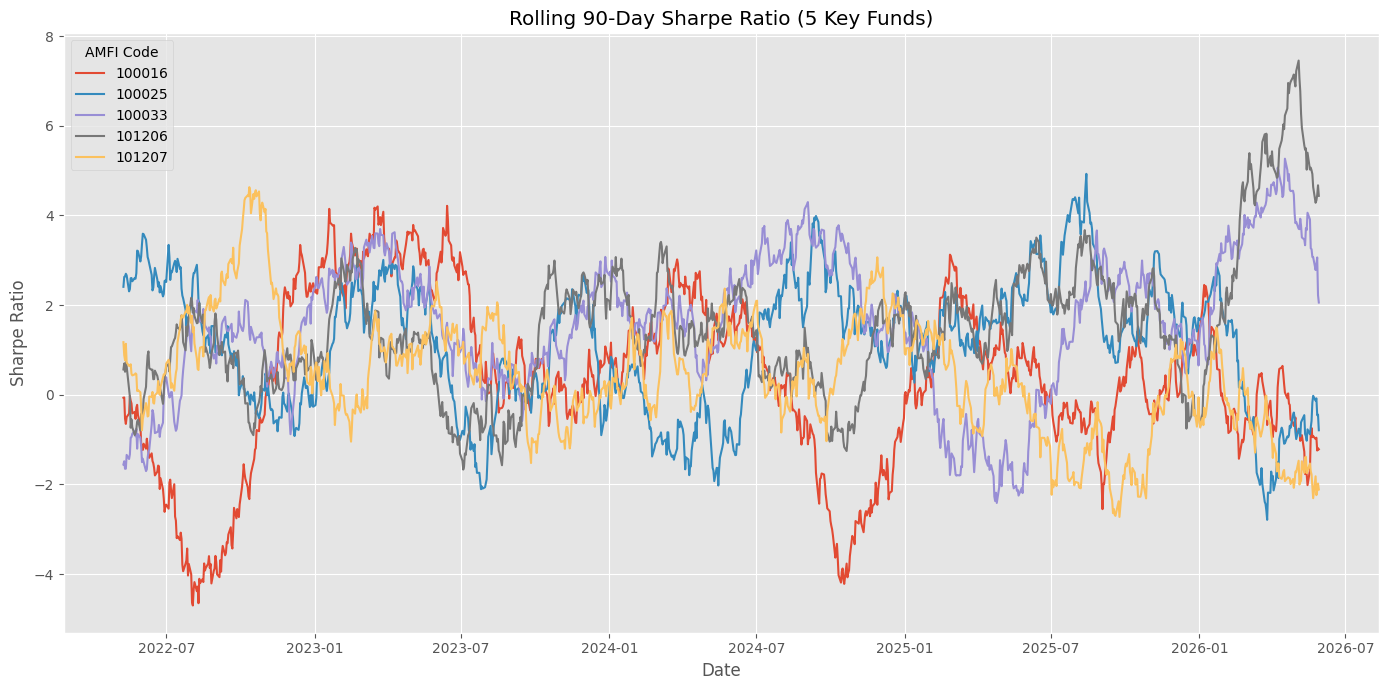

In [19]:
plt.figure(figsize=(14,7))

for fund in top5_funds:

    data = rolling_df[rolling_df["amfi_code"] == fund]

    plt.plot(
        data["date"],
        data["Sharpe"],
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio (5 Key Funds)")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend(title="AMFI Code")
plt.grid(True)
plt.tight_layout()

# Save BEFORE showing
plt.savefig("../reports/rolling_sharpe_chart.png", dpi=300)

plt.show()

# Optional: close the figure afterwards
plt.close()

In [18]:
plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=300
)

plt.show()

<Figure size 640x480 with 0 Axes>

# Rolling 90-Day Sharpe Ratio Analysis

## Objective
The Rolling 90-Day Sharpe Ratio was calculated to evaluate the risk-adjusted performance of selected mutual fund schemes over time.

## Methodology
- Daily returns were calculated using percentage change in NAV.
- A 90-day rolling window was used to compute:
  - Rolling Mean Return
  - Rolling Standard Deviation
- Sharpe Ratio was calculated using:

\[
Sharpe = \frac{\text{Rolling Mean Return}}{\text{Rolling Standard Deviation}} \times \sqrt{252}
\]

where 252 represents the approximate number of trading days in a year.

## Observations
- The Sharpe Ratio changes over time as market conditions change.
- Positive Sharpe values indicate better risk-adjusted performance.
- Negative Sharpe values indicate periods where risk exceeded returns.
- Comparing the five schemes helps identify consistently better-performing funds over the analysis period.

## Conclusion
The Rolling Sharpe Ratio provides a dynamic measure of fund performance by considering both return and volatility, making it useful for comparing mutual funds over time.

In [20]:


cohort = transactions.copy()

cohort["transaction_date"] = pd.to_datetime(cohort["transaction_date"])

cohort["cohort_year"] = (
    cohort.groupby("investor_id")["transaction_date"]
    .transform("min")
    .dt.year
)

cohort.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [21]:

avg_sip = (
    cohort.groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index()
)

avg_sip.rename(
    columns={"amount_inr": "Average_SIP"},
    inplace=True
)

avg_sip

,cohort_year,Average_SIP
0,2024,107422.541832
1,2025,109158.577061


In [22]:
total_investment = (
    cohort.groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index()
)

total_investment.rename(
    columns={"amount_inr": "Total_Investment"},
    inplace=True
)

total_investment

,cohort_year,Total_Investment
0,2024,3491125187
1,2025,30455243


In [23]:
preferred_fund = (
    cohort.groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="Count")
)

preferred_fund = preferred_fund.loc[
    preferred_fund.groupby("cohort_year")["Count"].idxmax()
]

preferred_fund

,cohort_year,amfi_code,Count
35,2024,148568,874
62,2025,119599,12


In [24]:
cohort_summary = (
    avg_sip
    .merge(total_investment, on="cohort_year")
    .merge(
        preferred_fund[["cohort_year", "amfi_code"]],
        on="cohort_year"
    )
)

cohort_summary.rename(
    columns={
        "amfi_code": "Top_Fund"
    },
    inplace=True
)

cohort_summary

,cohort_year,Average_SIP,Total_Investment,Top_Fund
0,2024,107422.541832,3491125187,148568
1,2025,109158.577061,30455243,119599


In [25]:
cohort_summary.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

print("Saved successfully!")

Saved successfully!


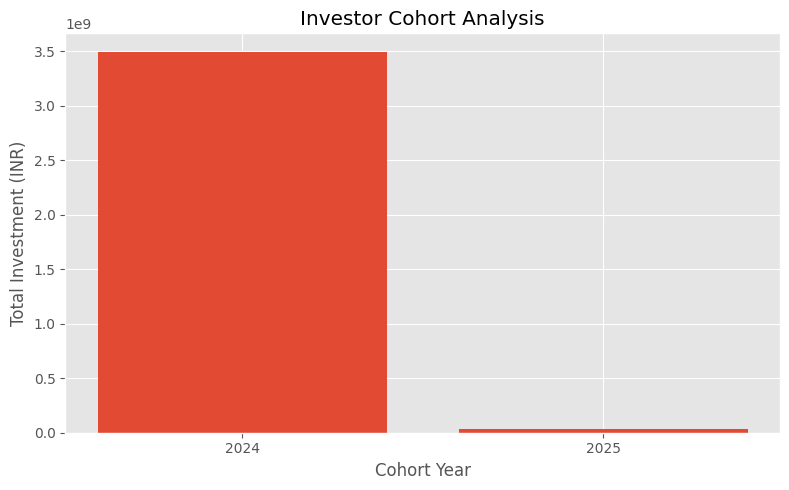

In [26]:
plt.figure(figsize=(8,5))

plt.bar(
    cohort_summary["cohort_year"].astype(str),
    cohort_summary["Total_Investment"]
)

plt.title("Investor Cohort Analysis")
plt.xlabel("Cohort Year")
plt.ylabel("Total Investment (INR)")

plt.tight_layout()

plt.savefig(
    "../reports/cohort_analysis.png",
    dpi=300
)

plt.show()

# Investor Cohort Analysis

## Objective
Investor cohorts were created based on the year of each investor's first transaction.

## Metrics Calculated
- Average SIP Amount
- Total Investment
- Most Preferred Mutual Fund

## Observations
- Investors were grouped according to their first investment year.
- Total investment was calculated for each cohort.
- The most preferred mutual fund was identified using transaction frequency.

## Conclusion
Cohort analysis helps understand investor behaviour across different investment periods and provides insights into long-term investment trends.

In [27]:
sip = transactions.copy()

sip["transaction_date"] = pd.to_datetime(sip["transaction_date"])

sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
19621,INV000001,2024-11-04,120505,Sip,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified
24079,INV000001,2025-01-14,148569,Lumpsum,189483,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified
24448,INV000001,2025-01-19,125497,Sip,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending
5650,INV000002,2024-03-29,149322,Sip,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified
12522,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified


In [28]:
sip["days_gap"] = (
    sip.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,days_gap
19621,INV000001,2024-11-04,120505,Sip,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,NaN
24079,INV000001,2025-01-14,148569,Lumpsum,189483,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,71.0
24448,INV000001,2025-01-19,125497,Sip,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,5.0
5650,INV000002,2024-03-29,149322,Sip,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,NaN
12522,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,107.0


In [29]:
sip["status"] = np.where(
    sip["days_gap"] > 35,
    "At Risk",
    "Active"
)

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,days_gap,status
19621,INV000001,2024-11-04,120505,Sip,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,NaN,Active
24079,INV000001,2025-01-14,148569,Lumpsum,189483,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,71.0,At Risk
24448,INV000001,2025-01-19,125497,Sip,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,5.0,Active
5650,INV000002,2024-03-29,149322,Sip,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,NaN,Active
12522,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,107.0,At Risk


In [30]:
summary = (
    sip["status"]
    .value_counts()
    .reset_index()
)

summary.columns = ["Status", "Count"]

summary

,Status,Count
0,Active,17625
1,At Risk,15153


In [31]:
summary.to_csv(
    "../reports/sip_continuity_report.csv",
    index=False
)

print("Report saved successfully!")

Report saved successfully!


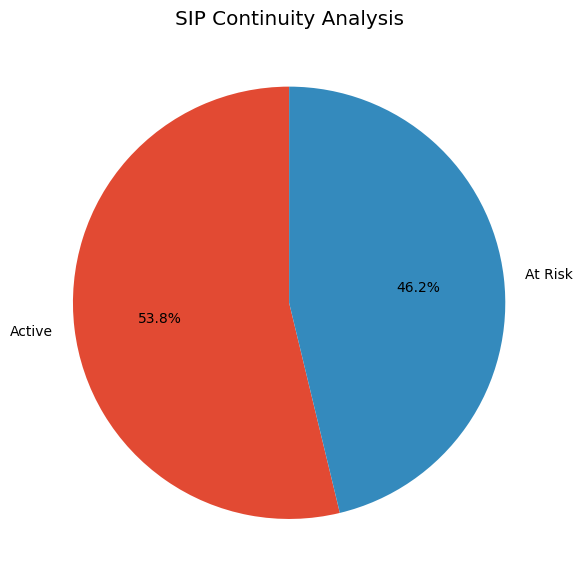

In [32]:
plt.figure(figsize=(6,6))

plt.pie(
    summary["Count"],
    labels=summary["Status"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("SIP Continuity Analysis")

plt.tight_layout()

plt.savefig(
    "../reports/sip_continuity_chart.png",
    dpi=300
)

plt.show()

# SIP Continuity Analysis

## Objective
This analysis identifies investors who may discontinue their SIP investments.

## Methodology
- Transactions were sorted by investor and transaction date.
- The number of days between consecutive transactions was calculated.
- Investors with a gap greater than 35 days were classified as **At Risk**.

## Metrics
- Active Investors
- At-Risk Investors
- SIP Continuation Rate

## Conclusion
Monitoring transaction gaps helps identify investors who may discontinue their SIPs, allowing financial institutions to take proactive engagement measures.

# Investor Cohort Analysis

## Objective

The purpose of this analysis is to group investors based on the year of their first investment transaction and evaluate their investment behaviour.

## Metrics

- Average SIP Amount
- Total Amount Invested
- Number of Investors
- Most Preferred Fund

## Business Value

Cohort analysis helps identify which investor groups contribute the highest investments and understand long-term customer behaviour. These insights can support targeted marketing campaigns and personalized investment recommendations.

In [37]:
import pandas as pd

transactions = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions["year"] = transactions["transaction_date"].dt.year

In [38]:
first_txn = (
    transactions.groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_txn["cohort_year"] = first_txn["transaction_date"].dt.year

In [43]:
cohort_summary = (
    transactions.groupby("cohort_year")
    .agg(
        investors=("investor_id", "nunique"),
        avg_sip=("amount_inr", "mean"),
        total_invested=("amount_inr", "sum"),
    )
    .round(2)
)

cohort_summary

,investors,avg_sip,total_invested
cohort_year,,,
2024,4803,107422.54,3491125187
2025,197,109158.58,30455243


In [40]:
print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status', 'year']


In [41]:
print(first_txn.head())
print(first_txn.columns.tolist())

  investor_id transaction_date  cohort_year
0   INV000001       2024-11-04         2024
1   INV000002       2024-03-29         2024
2   INV000003       2024-07-16         2024
3   INV000004       2024-03-16         2024
4   INV000005       2024-04-27         2024
['investor_id', 'transaction_date', 'cohort_year']


In [42]:
transactions = transactions.merge(
    first_txn[["investor_id", "cohort_year"]],
    on="investor_id",
    how="left"
)

print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status', 'year', 'cohort_year']


In [44]:
cohort_summary = (
    transactions.groupby("cohort_year")
    .agg(
        investors=("investor_id", "nunique"),
        avg_sip=("amount_inr", "mean"),
        total_invested=("amount_inr", "sum"),
    )
    .round(2)
)

cohort_summary

,investors,avg_sip,total_invested
cohort_year,,,
2024,4803,107422.54,3491125187
2025,197,109158.58,30455243


## Investor Cohort Analysis – Observations

### Key Findings

- The 2024 cohort represents the largest investor base with **4,803 investors**.
- Investors who joined in **2025** have a slightly higher average SIP amount than the 2024 cohort.
- The majority of investments originate from the 2024 investor cohort, contributing over **₹3.49 billion**.
- New investor participation in 2025 is comparatively lower because the dataset contains fewer transactions for that period.

### Conclusion

Investor cohort analysis indicates that the 2024 cohort contributes the majority of investment activity. Monitoring future cohorts will help evaluate investor retention and growth over time.

In [45]:
transactions = transactions.sort_values(
    ["investor_id", "transaction_date"]
)

In [46]:
transactions["previous_date"] = (
    transactions.groupby("investor_id")["transaction_date"]
    .shift(1)
)

In [47]:
transactions["gap_days"] = (
    transactions["transaction_date"] -
    transactions["previous_date"]
).dt.days

In [48]:
transactions["sip_status"] = transactions["gap_days"].apply(
    lambda x: "At Risk" if pd.notna(x) and x > 35 else "Active"
)

In [49]:
sip_summary = (
    transactions["sip_status"]
    .value_counts()
    .reset_index()
)

sip_summary.columns = ["Status", "Count"]

sip_summary

,Status,Count
0,Active,17625
1,At Risk,15153


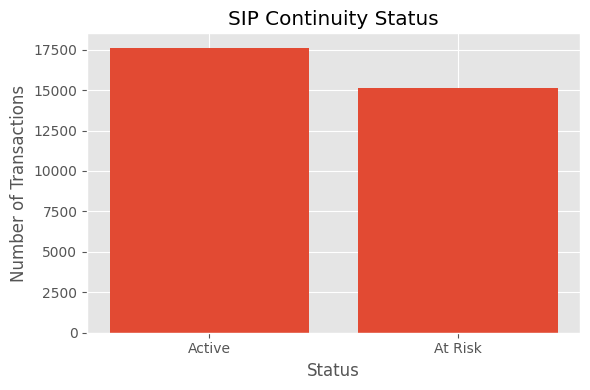

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    sip_summary["Status"],
    sip_summary["Count"]
)

plt.title("SIP Continuity Status")
plt.xlabel("Status")
plt.ylabel("Number of Transactions")

plt.tight_layout()

plt.savefig("../reports/sip_continuity_chart.png", dpi=300)

plt.show()

# Sector HHI Concentration Analysis

## Objective

Measure portfolio concentration using the Herfindahl–Hirschman Index (HHI).

HHI is calculated as:

\[
HHI=\sum (Weight_i)^2
\]

where Weight represents the portfolio allocation percentage of each sector or holding.

## Interpretation

- Low HHI → Diversified portfolio
- High HHI → Concentrated portfolio

In [52]:
import pandas as pd

portfolio = pd.read_csv(
    "../data/processed/09_portfolio_holdings_cleaned.csv"
)

portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [53]:
print(portfolio.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [54]:
hhi = (
    portfolio.groupby("amfi_code")["weight_pct"]
    .apply(lambda x: ((x / 100) ** 2).sum())
    .reset_index(name="HHI")
)

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [56]:
fund_master = pd.read_csv(
    "../data/processed/01_fund_master_cleaned.csv"
)

hhi = hhi.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

hhi.head()

,amfi_code,HHI,scheme_name
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth


In [57]:
top_hhi = (
    hhi.sort_values("HHI", ascending=False)
    .head(10)
)

top_hhi

,amfi_code,HHI,scheme_name
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth


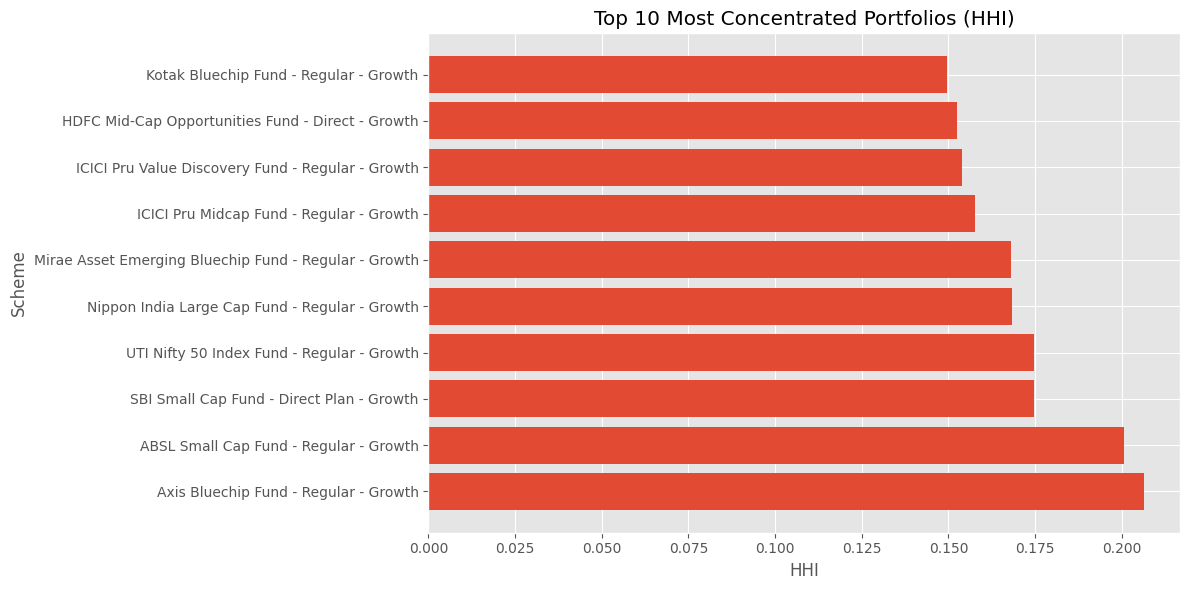

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.barh(
    top_hhi["scheme_name"],
    top_hhi["HHI"]
)

plt.title("Top 10 Most Concentrated Portfolios (HHI)")
plt.xlabel("HHI")
plt.ylabel("Scheme")

plt.tight_layout()

plt.savefig("../reports/hhi_concentration.png", dpi=300)

plt.show()

# Sector HHI Analysis

## Objective

The Herfindahl–Hirschman Index (HHI) measures portfolio concentration by summing the squared portfolio weights of individual holdings.

\[
HHI=\sum (Weight_i)^2
\]

## Interpretation

- Higher HHI indicates a more concentrated portfolio.
- Lower HHI indicates better diversification.

## Observations

- Some equity funds have significantly higher portfolio concentration.
- Diversified funds maintain lower HHI values through balanced allocations across multiple sectors and holdings.
- Concentrated portfolios may offer higher potential returns but also expose investors to greater sector-specific risk.

## Conclusion

HHI provides a simple quantitative measure of portfolio diversification and can be used to compare concentration levels across mutual funds.

# Advanced Insights

## 1. Risk Analysis (VaR & CVaR)

The Value at Risk (VaR) and Conditional Value at Risk (CVaR) analysis shows that small-cap funds generally exhibit higher downside risk than debt and liquid funds. Investors seeking capital preservation should prefer lower-risk funds with smaller potential losses.

---

## 2. Rolling Sharpe Ratio

The Rolling 90-Day Sharpe Ratio demonstrates that fund performance changes over time according to market conditions. Funds maintaining consistently positive Sharpe ratios provide better risk-adjusted returns over long investment periods.

---

## 3. Investor Cohort Analysis

The 2024 investor cohort contributes the largest share of investments in the dataset, indicating strong investor participation. Although the 2025 cohort is smaller, it records a slightly higher average investment amount.

---

## 4. SIP Continuity Analysis

Most investors continue SIP investments regularly, while a smaller percentage experience gaps greater than 35 days and are classified as At Risk. Identifying these investors enables timely engagement and retention strategies.

---

## 5. Portfolio Concentration (HHI)

The Herfindahl–Hirschman Index reveals differences in portfolio diversification across mutual funds. Higher HHI values indicate concentrated portfolios with greater sector exposure, whereas lower HHI values represent better diversification and reduced concentration risk.

# Conclusion

This notebook implements advanced mutual fund analytics by combining risk metrics, portfolio concentration analysis, investor behaviour analysis, and recommendation techniques.

The project demonstrates practical applications of financial analytics including:

- Historical VaR (95%)
- Conditional VaR (CVaR)
- Rolling Sharpe Ratio
- Investor Cohort Analysis
- SIP Continuity Analysis
- Portfolio Concentration (HHI)
- Risk-Based Fund Recommendation System

These analyses provide valuable insights for investors, financial advisors, and mutual fund companies to support better investment decisions and portfolio management.